# Track 1 · Part 1 — RadioML 2016.10A: Explore + Baseline Modulation Classifier
**Team Rover Rangers · MATLAB in Space Hackathon**

Pipeline:
1. Load the pickle into flat NumPy arrays (`X`, `y`, `snr`)
2. Sanity-check the dataset (counts, shapes, power vs SNR)
3. Visualize: constellations, time series, spectra
4. Preprocess + stratified train/val/test split
5. Train a 1D CNN on raw I/Q (runs on GPU if available, else CPU)
6. Evaluate: accuracy vs SNR, confusion matrices
7. Save model, plots, and metrics to `outputs/` for the repo

Dataset credit: O'Shea, T. J., & West, N. "Radio Machine Learning Dataset Generation with GNU Radio." GNU Radio Conference, 2016. DeepSig Inc., CC BY-NC-SA 4.0.

In [1]:
import os, json, time, pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# ---- Config ----
DATA_PATH = "RML2016.10a_dict.pkl"   # change if the file lives elsewhere (e.g. HPC scratch)
OUT_DIR   = "outputs"
SEED      = 42
EPOCHS    = 25          # early stopping usually ends sooner
BATCH     = 512
LR        = 1e-3
QUICK     = False      # True = train on 20% of data for a fast smoke test

os.makedirs(OUT_DIR, exist_ok=True)
np.random.seed(SEED)

## 1. Load
The pickle is a dict keyed by `(modulation, snr)`, each value shaped `(1000, 2, 128)`: 1000 examples, I/Q rows, 128 samples.
We flatten it into one array `X` of shape `(220000, 2, 128)` plus label (`y`) and SNR (`snr`) arrays. Keeping SNR per example is essential: the headline result is accuracy **as a function of SNR**.

In [2]:
with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

MODS = sorted({k[0] for k in data})
SNRS = sorted({k[1] for k in data})

X_list, y_list, s_list = [], [], []
for (mod, s), v in data.items():
    X_list.append(v)
    y_list.append(np.full(len(v), MODS.index(mod)))
    s_list.append(np.full(len(v), s))
X   = np.concatenate(X_list).astype(np.float32)
y   = np.concatenate(y_list)
snr = np.concatenate(s_list)
del data, X_list

print("X:", X.shape, "| mods:", len(MODS), "| SNRs:", SNRS[0], "to", SNRS[-1])
print(MODS)

X: (220000, 2, 128) | mods: 11 | SNRs: -20 to 18
['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']


## 2. Sanity checks

In [3]:
assert X.shape == (220000, 2, 128), X.shape
counts = {m: int((y == i).sum()) for i, m in enumerate(MODS)}
print("examples per modulation:", counts)

# Mean signal power per SNR. Each example is (signal + noise); if power rises with SNR,
# the noise floor is roughly fixed and the signal grows.
power = (X ** 2).sum(axis=1).mean(axis=1)    # per-example mean |x|^2
for s in SNRS[::4]:
    print(f"SNR {s:+3d} dB  mean power {power[snr == s].mean():.4f}")

examples per modulation: {'8PSK': 20000, 'AM-DSB': 20000, 'AM-SSB': 20000, 'BPSK': 20000, 'CPFSK': 20000, 'GFSK': 20000, 'PAM4': 20000, 'QAM16': 20000, 'QAM64': 20000, 'QPSK': 20000, 'WBFM': 20000}
SNR -20 dB  mean power 0.0001
SNR -12 dB  mean power 0.0001
SNR  -4 dB  mean power 0.0001
SNR  +4 dB  mean power 0.0001
SNR +12 dB  mean power 0.0001


## 3. Visualize
- **Constellations (I vs Q)** at high SNR show the structure a classifier must learn (QPSK = 4 clusters, QAM16 = grid, ...). Note they're rotated/smeared, because the dataset adds frequency offset, phase noise, and multipath.
- **Same modulation across SNRs** shows how quickly structure disappears into noise.
- **Spectra** separate the analog (AM, WBFM) and FSK (CPFSK, GFSK) families from the PSK/QAM family.

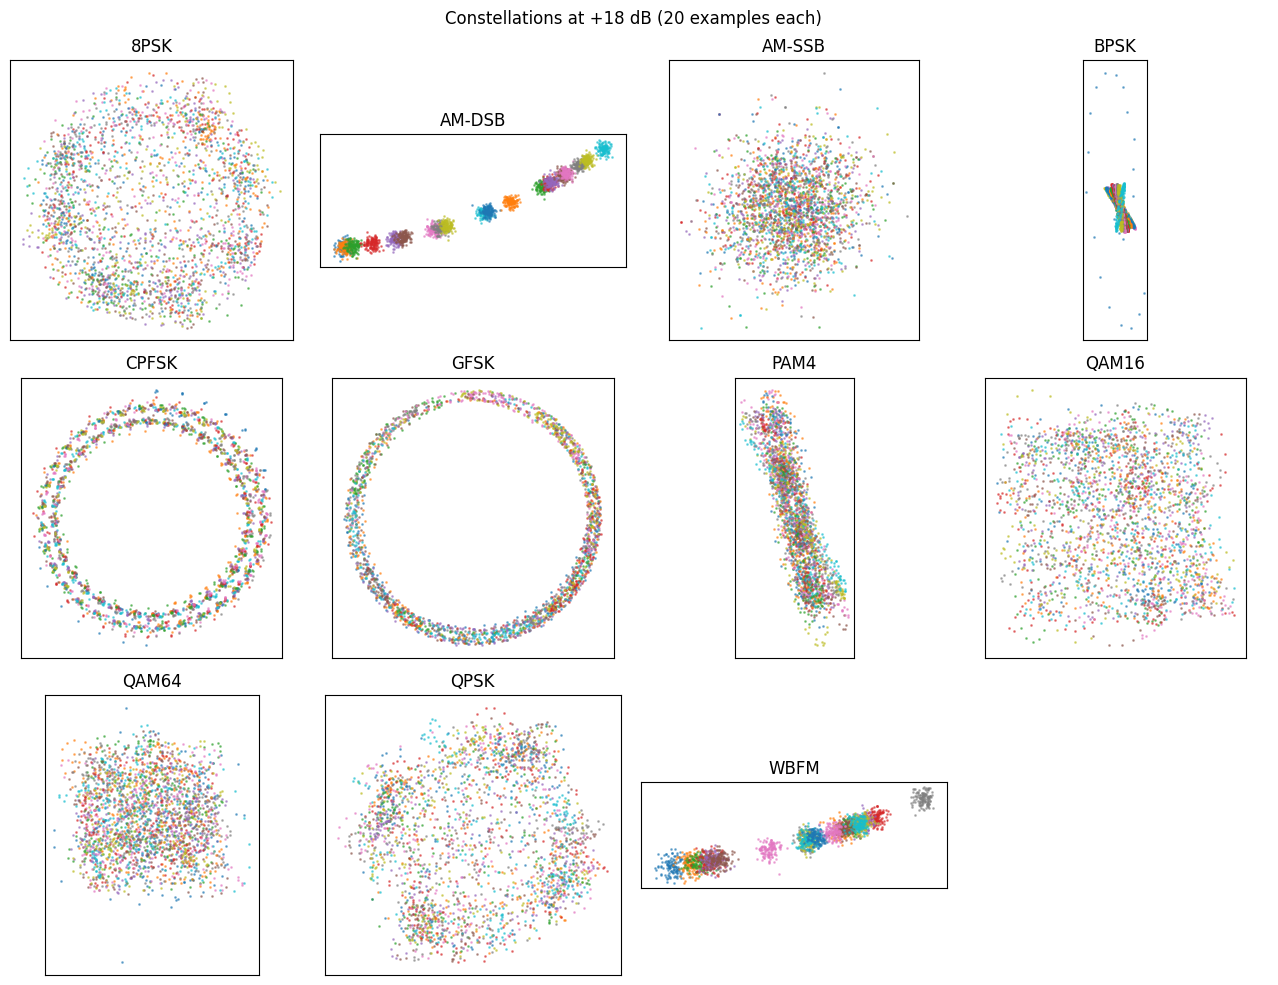

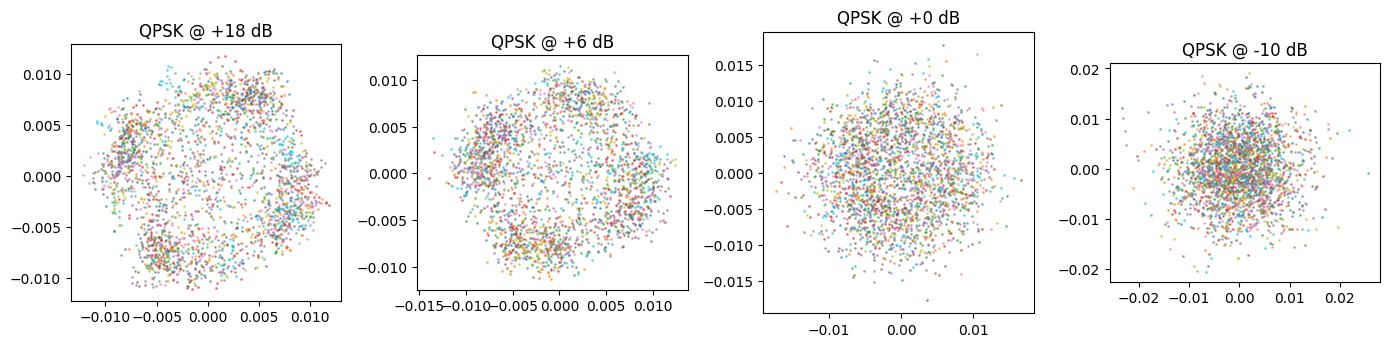

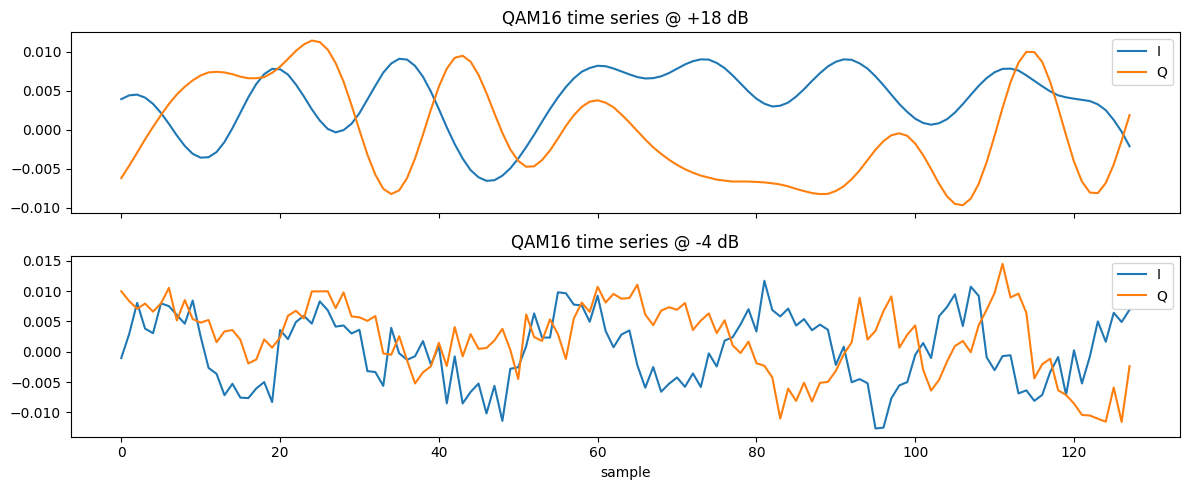

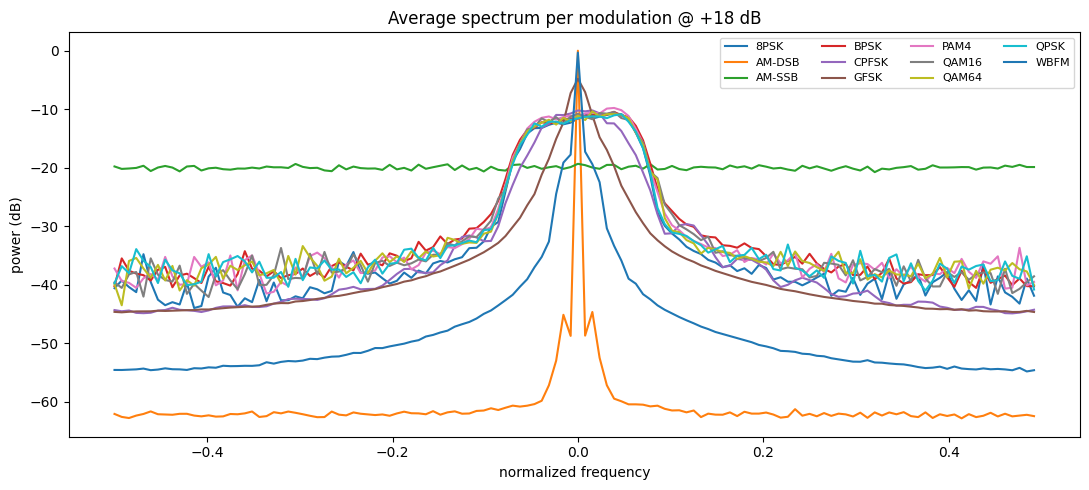

In [4]:
def iq(i):  # complex samples of example i
    return X[i, 0] + 1j * X[i, 1]

def pick(mod, s, n=1):
    idx = np.where((y == MODS.index(mod)) & (snr == s))[0]
    return idx[:n]

# 3a. Constellations at +18 dB, 20 examples overlaid per modulation
fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, mod in zip(axes.flat, MODS):
    for i in pick(mod, 18, 20):
        z = iq(i); ax.plot(z.real, z.imag, ".", ms=2, alpha=0.5)
    ax.set_title(mod); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
axes.flat[-1].axis("off")
fig.suptitle("Constellations at +18 dB (20 examples each)")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/constellations_18dB.png", dpi=150); plt.show()

# 3b. QPSK at several SNRs
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, s in zip(axes, [18, 6, 0, -10]):
    for i in pick("QPSK", s, 20):
        z = iq(i); ax.plot(z.real, z.imag, ".", ms=2, alpha=0.5)
    ax.set_title(f"QPSK @ {s:+d} dB"); ax.set_aspect("equal")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/qpsk_vs_snr.png", dpi=150); plt.show()

# 3c. Time-domain I/Q of one example
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
for ax, s in zip(axes, [18, -4]):
    i = pick("QAM16", s)[0]
    ax.plot(X[i, 0], label="I"); ax.plot(X[i, 1], label="Q")
    ax.set_title(f"QAM16 time series @ {s:+d} dB"); ax.legend(loc="upper right")
axes[-1].set_xlabel("sample")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/time_series.png", dpi=150); plt.show()

# 3d. Average power spectrum per modulation at +18 dB
fig, ax = plt.subplots(figsize=(11, 5))
f = np.fft.fftshift(np.fft.fftfreq(128))
for mod in MODS:
    idx = pick(mod, 18, 200)
    Z = X[idx, 0] + 1j * X[idx, 1]
    P = np.mean(np.abs(np.fft.fftshift(np.fft.fft(Z, axis=1), axes=1)) ** 2, axis=0)
    ax.plot(f, 10 * np.log10(P + 1e-12), label=mod)
ax.set_xlabel("normalized frequency"); ax.set_ylabel("power (dB)")
ax.set_title("Average spectrum per modulation @ +18 dB"); ax.legend(ncol=4, fontsize=8)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/spectra_18dB.png", dpi=150); plt.show()

## 4. Preprocess + split
- **Per-example RMS normalization**: scales every example to unit power, so the model can't cheat by reading absolute amplitude and generalizes across gain changes, which matters for real receivers with no hand-tuned gain ("no human tuning").
- **Stratified 70/15/15 split** on (modulation, SNR) pairs, so every SNR is equally represented in train, val, and test.

In [5]:
rms = np.sqrt((X ** 2).sum(axis=1).mean(axis=1, keepdims=True))[:, None, :]   # (N,1,1)
Xn = X / (rms + 1e-8)

strat = y * 100 + (snr + 20)      # unique id for each (mod, snr) pair
idx_all = np.arange(len(y))
if QUICK:
    idx_all, _ = train_test_split(idx_all, train_size=0.2, stratify=strat, random_state=SEED)
tr, tmp = train_test_split(idx_all, test_size=0.30, stratify=strat[idx_all], random_state=SEED)
va, te  = train_test_split(tmp,     test_size=0.50, stratify=strat[tmp],     random_state=SEED)
print(f"train {len(tr)}  val {len(va)}  test {len(te)}")

train 154000  val 33000  test 33000


## 5. Model: 1D CNN on raw I/Q
Input `(2, 128)` treated as a 2-channel time series. Four conv blocks learn local waveform patterns (symbol transitions, phase jumps); global average pooling makes it insensitive to *where* in the window a pattern occurs. ~150k parameters; trains in minutes on GPU, ~10–30 min on a laptop CPU.

In [6]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print("device:", device)

def loader(idx, shuffle):
    ds = TensorDataset(torch.from_numpy(Xn[idx]), torch.from_numpy(y[idx]).long())
    return DataLoader(ds, batch_size=BATCH, shuffle=shuffle, num_workers=0)

train_dl, val_dl, test_dl = loader(tr, True), loader(va, False), loader(te, False)

def block(cin, cout, k, pool=True):
    layers = [nn.Conv1d(cin, cout, k, padding=k // 2), nn.BatchNorm1d(cout), nn.ReLU()]
    if pool: layers.append(nn.MaxPool1d(2))
    return nn.Sequential(*layers)

class IQNet(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.features = nn.Sequential(
            block(2, 64, 7), block(64, 64, 5), block(64, 128, 3), block(128, 128, 3, pool=False))
        self.head = nn.Sequential(nn.AdaptiveAvgPool1d(1), nn.Flatten(),
                                  nn.Dropout(0.3), nn.Linear(128, n_classes))
    def forward(self, x):
        return self.head(self.features(x))

model = IQNet(len(MODS)).to(device)
print(f"params: {sum(p.numel() for p in model.parameters()):,}")

device: cuda
params: 97,675


## 6. Train (early stopping on validation accuracy)

In [7]:
opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=2)
loss_fn = nn.CrossEntropyLoss()

def predict(dl):
    model.eval(); preds = []
    with torch.no_grad():
        for xb, _ in dl:
            preds.append(model(xb.to(device)).argmax(1).cpu())
    return torch.cat(preds).numpy()

history, best, patience, bad = [], 0.0, 5, 0
for ep in range(1, EPOCHS + 1):
    model.train(); t0, tot = time.time(), 0.0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad(); loss = loss_fn(model(xb), yb); loss.backward(); opt.step()
        tot += loss.item() * len(xb)
    val_acc = (predict(val_dl) == y[va]).mean()
    sched.step(val_acc)
    history.append({"epoch": ep, "train_loss": tot / len(tr), "val_acc": float(val_acc)})
    print(f"ep {ep:2d}  loss {tot/len(tr):.4f}  val_acc {val_acc:.4f}  ({time.time()-t0:.0f}s)")
    if val_acc > best:
        best, bad = val_acc, 0
        torch.save(model.state_dict(), f"{OUT_DIR}/iqnet_best.pt")
    else:
        bad += 1
        if bad >= patience: print("early stop"); break

model.load_state_dict(torch.load(f"{OUT_DIR}/iqnet_best.pt", map_location=device))

ep  1  loss 1.4418  val_acc 0.5272  (4s)
ep  2  loss 1.2461  val_acc 0.5291  (3s)
ep  3  loss 1.2086  val_acc 0.5497  (3s)
ep  4  loss 1.1820  val_acc 0.5283  (3s)
ep  5  loss 1.1643  val_acc 0.5639  (3s)
ep  6  loss 1.1488  val_acc 0.5658  (3s)
ep  7  loss 1.1418  val_acc 0.5665  (3s)
ep  8  loss 1.1341  val_acc 0.5642  (3s)
ep  9  loss 1.1246  val_acc 0.5644  (3s)
ep 10  loss 1.1178  val_acc 0.5711  (3s)
ep 11  loss 1.1093  val_acc 0.5746  (3s)
ep 12  loss 1.1042  val_acc 0.5803  (3s)
ep 13  loss 1.0970  val_acc 0.5849  (3s)
ep 14  loss 1.0879  val_acc 0.5828  (3s)
ep 15  loss 1.0824  val_acc 0.5769  (3s)
ep 16  loss 1.0755  val_acc 0.5701  (3s)
ep 17  loss 1.0519  val_acc 0.5886  (3s)
ep 18  loss 1.0434  val_acc 0.5860  (3s)
ep 19  loss 1.0377  val_acc 0.5909  (3s)
ep 20  loss 1.0318  val_acc 0.5811  (3s)
ep 21  loss 1.0274  val_acc 0.5832  (3s)
ep 22  loss 1.0225  val_acc 0.5849  (3s)
ep 23  loss 1.0018  val_acc 0.5895  (3s)
ep 24  loss 0.9968  val_acc 0.5848  (3s)
early stop


/tmp/ipykernel_2540755/1781666212.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{OUT_DIR}/iqnet_best.pt", map_location=device))


<All keys matched successfully>

## 7. Evaluate on the held-out test set
- **Accuracy vs SNR**: the standard RadioML result. Expect near chance (~9%) at -20 dB and a plateau around 80–90% at high SNR.
- **Confusion matrices**: at high SNR, the usual leftover errors are QAM16 ↔ QAM64 (only 128 samples to tell the grids apart) and AM-DSB ↔ WBFM (silent segments in the source audio make them look alike; a known dataset quirk).

overall test acc: 0.5909 | SNR >= 0 dB: 0.8765


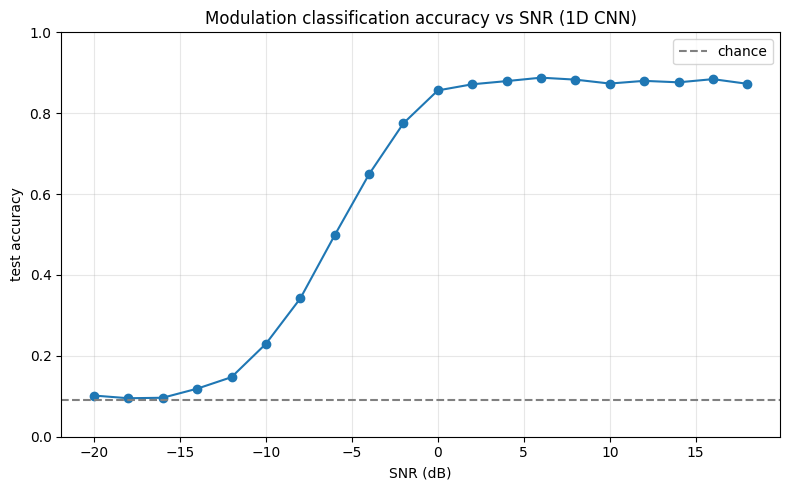

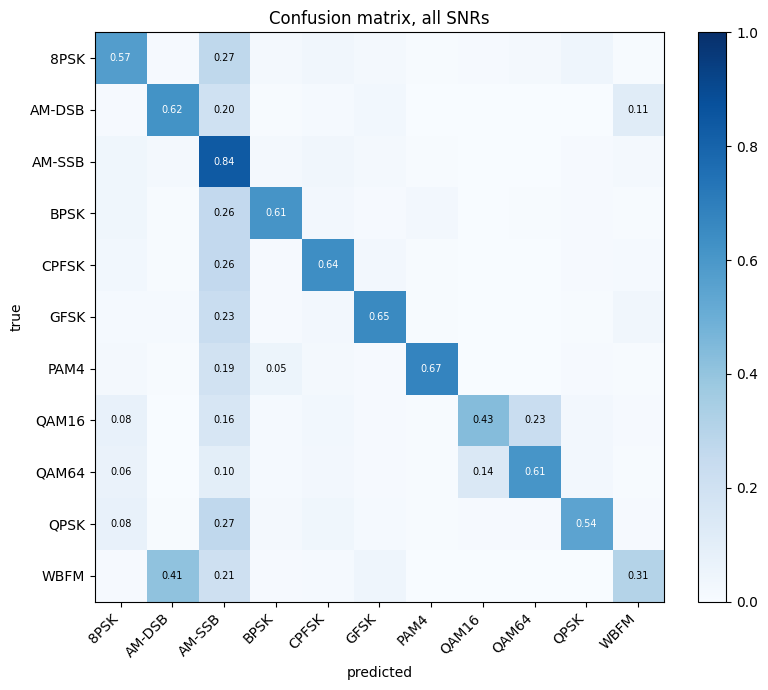

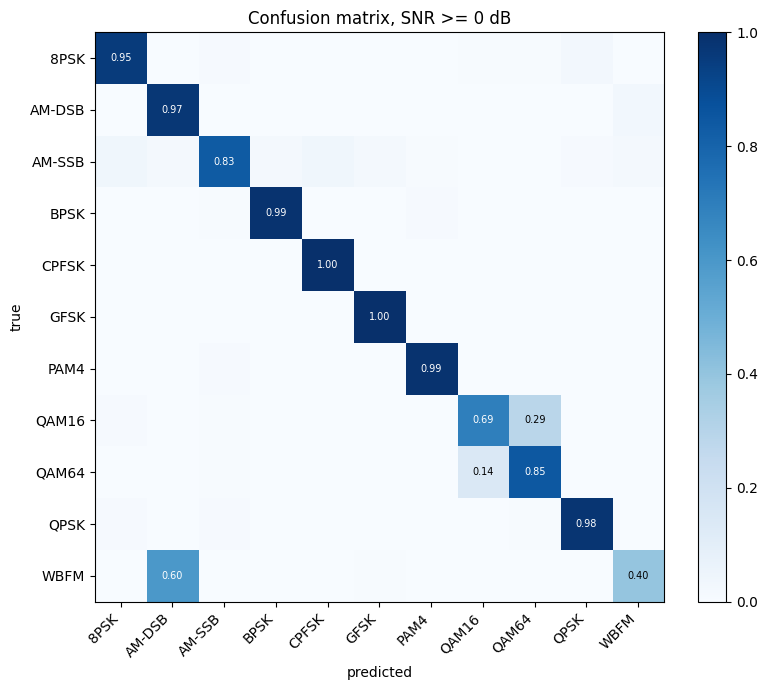

In [8]:
y_pred = predict(test_dl)
y_true, s_te = y[te], snr[te]
overall = float((y_pred == y_true).mean())
acc_by_snr = {int(s): float((y_pred[s_te == s] == y_true[s_te == s]).mean()) for s in SNRS}
hi = s_te >= 0
print(f"overall test acc: {overall:.4f} | SNR >= 0 dB: {(y_pred[hi]==y_true[hi]).mean():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(acc_by_snr), list(acc_by_snr.values()), "o-")
ax.axhline(1 / len(MODS), ls="--", c="gray", label="chance")
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("test accuracy"); ax.set_ylim(0, 1)
ax.set_title("Modulation classification accuracy vs SNR (1D CNN)"); ax.grid(alpha=0.3); ax.legend()
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/acc_vs_snr.png", dpi=150); plt.show()

def plot_cm(mask, title, fname):
    cm = confusion_matrix(y_true[mask], y_pred[mask], labels=range(len(MODS)), normalize="true")
    fig, ax = plt.subplots(figsize=(8, 7))
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(MODS))); ax.set_xticklabels(MODS, rotation=45, ha="right")
    ax.set_yticks(range(len(MODS))); ax.set_yticklabels(MODS)
    for i in range(len(MODS)):
        for j in range(len(MODS)):
            if cm[i, j] >= 0.05:
                ax.text(j, i, f"{cm[i,j]:.2f}", ha="center", va="center",
                        color="white" if cm[i, j] > 0.5 else "black", fontsize=7)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    fig.colorbar(im, fraction=0.046); fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/{fname}", dpi=150); plt.show()

plot_cm(np.ones_like(hi), "Confusion matrix, all SNRs", "cm_all.png")
plot_cm(hi, "Confusion matrix, SNR >= 0 dB", "cm_high_snr.png")

## 8. Save metrics for the README

In [9]:
metrics = {"overall_test_acc": overall,
           "test_acc_snr_ge_0": float((y_pred[hi] == y_true[hi]).mean()),
           "acc_by_snr": acc_by_snr, "history": history,
           "n_train": len(tr), "n_val": len(va), "n_test": len(te), "device": device}
with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("saved to", OUT_DIR, "->", sorted(os.listdir(OUT_DIR)))

saved to outputs -> ['acc_vs_snr.png', 'cfo_accuracy.png', 'cfo_accuracy_blind.png', 'cfo_constellations.png', 'cfo_estimator.png', 'cfo_metrics.json', 'cm_all.png', 'cm_high_snr.png', 'constellations_18dB.png', 'iqnet_best.pt', 'metrics.json', 'qpsk_vs_snr.png', 'rml2018', 'spectra_18dB.png', 'time_series.png']


## Cell A: Doppler injection, correction, and accuracy curves

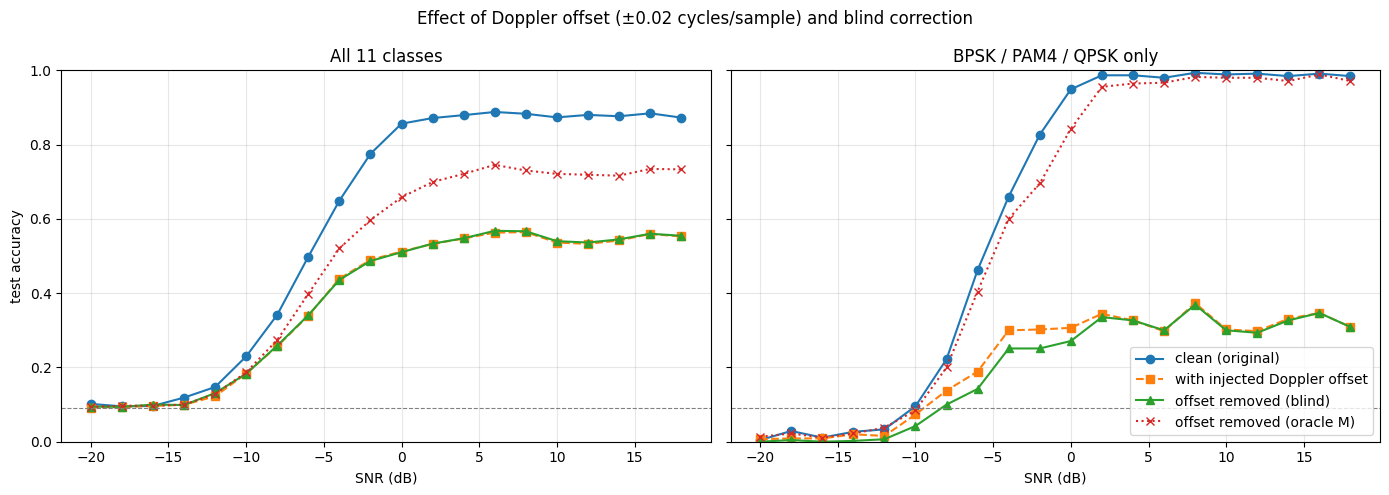

clean            acc all=0.591  BPSK/PAM4/QPSK @SNR>=0=0.984
Doppler          acc all=0.383  BPSK/PAM4/QPSK @SNR>=0=0.324
blind-corrected  acc all=0.384  BPSK/PAM4/QPSK @SNR>=0=0.318
oracle           acc all=0.484  BPSK/PAM4/QPSK @SNR>=0=0.960


In [10]:
rng = np.random.default_rng(SEED)
N_S = X.shape[2]
n = np.arange(N_S)
MAX_CFO = 0.02          # max injected offset, cycles/sample (~2.5 rotations over 128 samples)

def to_c(x):  return x[:, 0] + 1j * x[:, 1]
def to_iq(z): return np.stack([z.real, z.imag], axis=1).astype(np.float32)

def add_cfo(x, max_f=MAX_CFO):
    f = rng.uniform(-max_f, max_f, size=(len(x), 1))
    return to_iq(to_c(x) * np.exp(2j * np.pi * f * n)), f.ravel()

# M-th power estimator: z**M removes the data and leaves a tone at M * offset
POWER = {"BPSK": 2, "PAM4": 2, "QPSK": 4}
def est_cfo(z, M, fmax=0.03, nfft=8192):
    fr = np.fft.fftfreq(nfft)
    keep = np.abs(fr) <= M * fmax
    S = np.abs(np.fft.fft(z ** M, nfft, axis=1))[:, keep]
    return fr[keep][S.argmax(1)] / M

def correct(x, labels):
    z = to_c(x); f_hat = np.zeros(len(z))
    for mod, M in POWER.items():
        m = labels == MODS.index(mod)
        if m.any(): f_hat[m] = est_cfo(z[m], M)
    return to_iq(z * np.exp(-2j * np.pi * f_hat[:, None] * n)), f_hat

def predict_np(x, bs=4096):
    xn = x / (np.sqrt((x ** 2).sum(axis=1).mean(axis=1))[:, None, None] + 1e-8)
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(xn), bs):
            out.append(model(torch.from_numpy(xn[i:i + bs]).to(device)).argmax(1).cpu())
    return torch.cat(out).numpy()

Xte, yte, ste = X[te], y[te], snr[te]
Xcfo, f_true = add_cfo(Xte)
p_clean = predict_np(Xte)
p_cfo   = predict_np(Xcfo)
Xblind, f_blind = correct(Xcfo, p_cfo)   # blind: M chosen from the model's own prediction
p_blind = predict_np(Xblind)
Xorac, f_orac = correct(Xcfo, yte)       # oracle: M chosen from the true class
p_orac = predict_np(Xorac)

def acc_curve(p, mask=None):
    mask = np.ones(len(p), bool) if mask is None else mask
    return [float((p[mask & (ste == s)] == yte[mask & (ste == s)]).mean()) for s in SNRS]

psk = np.isin(yte, [MODS.index(m) for m in POWER])
cfo_results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, mask, title in [(axes[0], None, "All 11 classes"), (axes[1], psk, "BPSK / PAM4 / QPSK only")]:
    for p, lab, st in [(p_clean, "clean (original)", "o-"), (p_cfo, "with injected Doppler offset", "s--"),
                       (p_blind, "offset removed (blind)", "^-"), (p_orac, "offset removed (oracle M)", "x:")]:
        c = acc_curve(p, mask); ax.plot(SNRS, c, st, label=lab)
        cfo_results[f"{title} | {lab}"] = dict(zip(map(int, SNRS), c))
    ax.axhline(1 / len(MODS), c="gray", ls="--", lw=0.8)
    ax.set_title(title); ax.set_xlabel("SNR (dB)"); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
axes[0].set_ylabel("test accuracy"); axes[1].legend(loc="lower right")
fig.suptitle(f"Effect of Doppler offset (±{MAX_CFO} cycles/sample) and blind correction")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/cfo_accuracy.png", dpi=150); plt.show()

hi_psk = psk & (ste >= 0)
for p, lab in [(p_clean, "clean"), (p_cfo, "Doppler"), (p_blind, "blind-corrected"), (p_orac, "oracle")]:
    print(f"{lab:16s} acc all={np.mean(p == yte):.3f}  BPSK/PAM4/QPSK @SNR>=0={np.mean(p[hi_psk] == yte[hi_psk]):.3f}")

## Cell B: estimator accuracy and before/after constellations

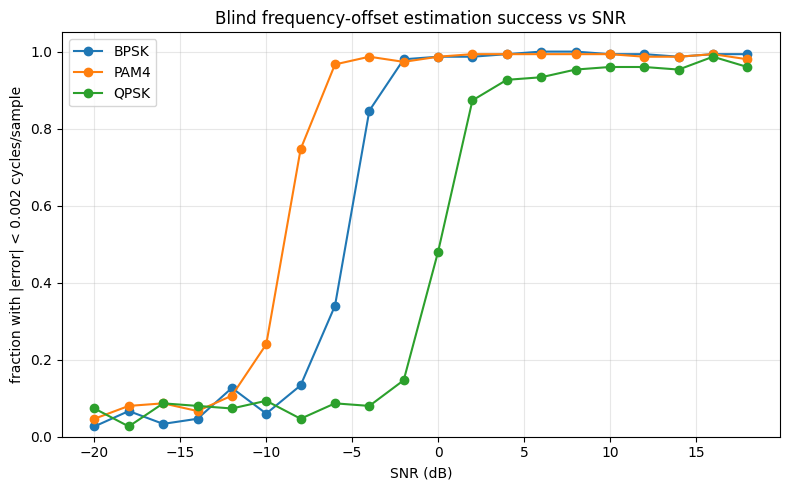

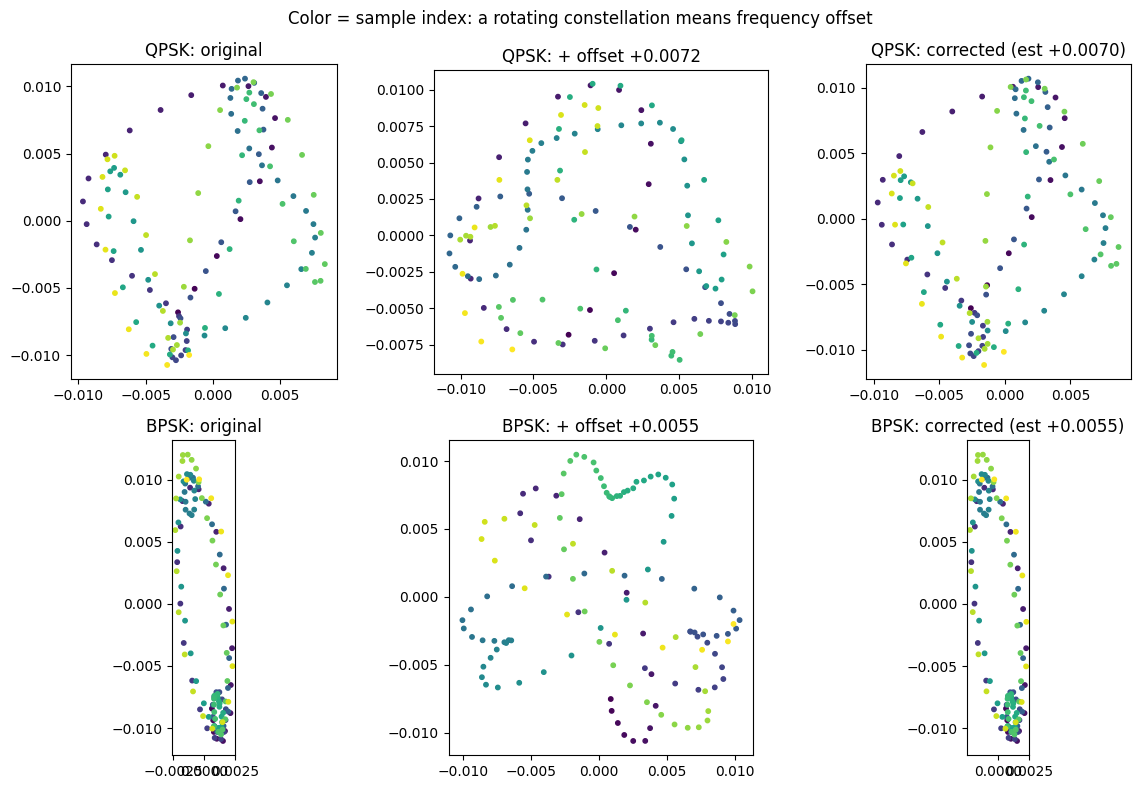

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
for mod in POWER:
    m = yte == MODS.index(mod)
    err = np.abs(f_orac[m] - f_true[m])
    ax.plot(SNRS, [float((err[ste[m] == s] < 0.002).mean()) for s in SNRS], "o-", label=mod)
ax.set_xlabel("SNR (dB)"); ax.set_ylabel("fraction with |error| < 0.002 cycles/sample")
ax.set_title("Blind frequency-offset estimation success vs SNR"); ax.grid(alpha=0.3); ax.legend(); ax.set_ylim(0, 1.05)
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/cfo_estimator.png", dpi=150); plt.show()

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for row, mod in zip(axes, ["QPSK", "BPSK"]):
    i = np.where((yte == MODS.index(mod)) & (ste == 18))[0][0]
    for ax, (arr, t) in zip(row, [(Xte, "original"), (Xcfo, f"+ offset {f_true[i]:+.4f}"),
                                  (Xorac, f"corrected (est {f_orac[i]:+.4f})")]):
        z = arr[i, 0] + 1j * arr[i, 1]
        ax.scatter(z.real, z.imag, c=np.arange(N_S), cmap="viridis", s=10)
        ax.set_title(f"{mod}: {t}"); ax.set_aspect("equal")
fig.suptitle("Color = sample index: a rotating constellation means frequency offset")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/cfo_constellations.png", dpi=150); plt.show()

with open(f"{OUT_DIR}/cfo_metrics.json", "w") as f:
    json.dump({"max_injected_cfo": MAX_CFO, "accuracy_by_snr": cfo_results}, f, indent=2)

## Fully blind Doppler correction via hypothesis testing (try M = 2 and M = 4, keep the consistent reclassification)

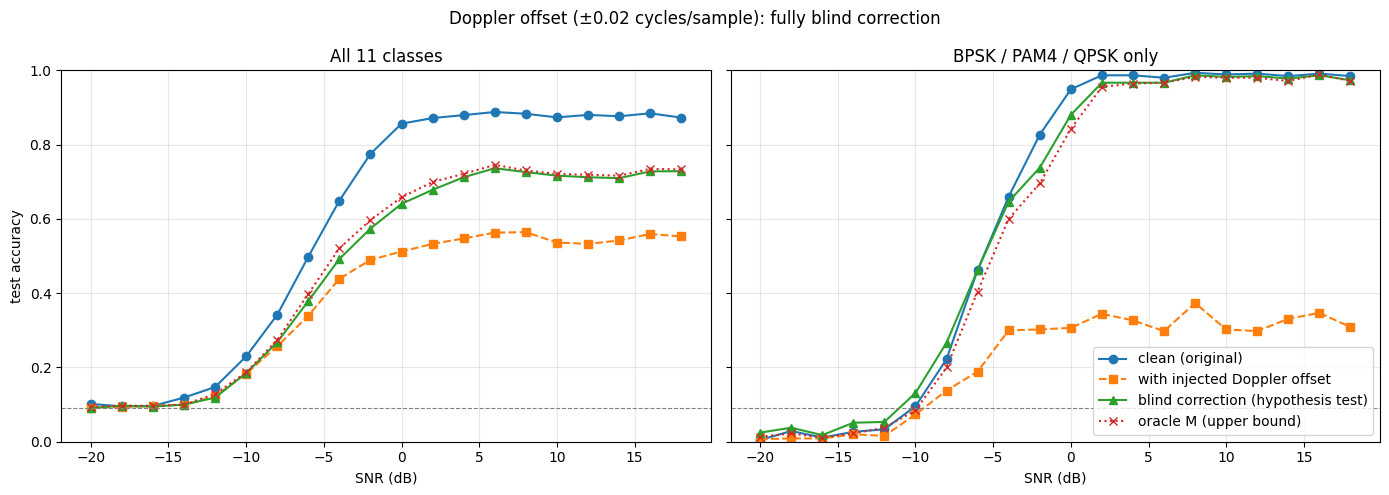

clean              acc all=0.591  BPSK/PAM4/QPSK @SNR>=0=0.984  others @SNR>=0=0.836
Doppler            acc all=0.383  BPSK/PAM4/QPSK @SNR>=0=0.324  others @SNR>=0=0.627
blind (hyp. test)  acc all=0.474  BPSK/PAM4/QPSK @SNR>=0=0.967  others @SNR>=0=0.612
oracle             acc all=0.484  BPSK/PAM4/QPSK @SNR>=0=0.960  others @SNR>=0=0.627


In [12]:
def est_cfo(z, M, fmax=0.03, nfft=2048, chunk=2000):
    fr = np.fft.fftfreq(nfft)
    keep = np.abs(fr) <= M * fmax
    out = np.empty(len(z))
    for i in range(0, len(z), chunk):
        S = np.abs(np.fft.fft(z[i:i + chunk] ** M, nfft, axis=1))[:, keep]
        out[i:i + chunk] = fr[keep][S.argmax(1)] / M
    return out

def predict_proba(x, bs=4096):
    xn = x / (np.sqrt((x ** 2).sum(axis=1).mean(axis=1))[:, None, None] + 1e-8)
    model.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(xn), bs):
            out.append(torch.softmax(model(torch.from_numpy(xn[i:i + bs]).to(device)), 1).cpu())
    return torch.cat(out).numpy()

HYP = {2: ["BPSK", "PAM4"], 4: ["QPSK", "BPSK", "PAM4"]}
z = to_c(Xcfo)
P0 = predict_proba(Xcfo)
p_hyp = P0.argmax(1).copy()
best_conf = np.full(len(z), -1.0)
f_hyp = np.zeros(len(z))
for M, ok_mods in HYP.items():
    f_hat = est_cfo(z, M)
    P = predict_proba(to_iq(z * np.exp(-2j * np.pi * f_hat[:, None] * n)))
    pred, conf = P.argmax(1), P.max(1)
    accept = np.isin(pred, [MODS.index(m) for m in ok_mods]) & (conf > best_conf)
    p_hyp[accept] = pred[accept]
    best_conf[accept] = conf[accept]
    f_hyp[accept] = f_hat[accept]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, mask, title in [(axes[0], None, "All 11 classes"), (axes[1], psk, "BPSK / PAM4 / QPSK only")]:
    for p, lab, st in [(p_clean, "clean (original)", "o-"),
                       (p_cfo, "with injected Doppler offset", "s--"),
                       (p_hyp, "blind correction (hypothesis test)", "^-"),
                       (p_orac, "oracle M (upper bound)", "x:")]:
        c = acc_curve(p, mask)
        ax.plot(SNRS, c, st, label=lab)
        cfo_results[f"{title} | {lab}"] = dict(zip(map(int, SNRS), c))
    ax.axhline(1 / len(MODS), c="gray", ls="--", lw=0.8)
    ax.set_title(title); ax.set_xlabel("SNR (dB)"); ax.grid(alpha=0.3); ax.set_ylim(0, 1)
axes[0].set_ylabel("test accuracy")
axes[1].legend(loc="lower right")
fig.suptitle(f"Doppler offset (±{MAX_CFO} cycles/sample): fully blind correction")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/cfo_accuracy_blind.png", dpi=150); plt.show()

for p, lab in [(p_clean, "clean"), (p_cfo, "Doppler"), (p_hyp, "blind (hyp. test)"), (p_orac, "oracle")]:
    print(f"{lab:18s} acc all={np.mean(p == yte):.3f}  "
          f"BPSK/PAM4/QPSK @SNR>=0={np.mean(p[hi_psk] == yte[hi_psk]):.3f}  "
          f"others @SNR>=0={np.mean(p[~psk & (ste >= 0)] == yte[~psk & (ste >= 0)]):.3f}")

with open(f"{OUT_DIR}/cfo_metrics.json", "w") as f:
    json.dump({"max_injected_cfo": MAX_CFO, "accuracy_by_snr": cfo_results}, f, indent=2)

comparison


In [13]:
def similarity(a, b):
    za, zb = to_c(a), to_c(b)
    return np.abs((za * zb.conj()).sum(1)) / (np.linalg.norm(za, axis=1) * np.linalg.norm(zb, axis=1))

for mod in ["BPSK", "PAM4", "QPSK"]:
    m = (yte == MODS.index(mod)) & (ste >= 0)
    print(f"{mod:5s} similarity to original: with Doppler {similarity(Xte[m], Xcfo[m]).mean():.3f} "
          f"-> after correction {similarity(Xte[m], Xorac[m]).mean():.3f}")

BPSK  similarity to original: with Doppler 0.308 -> after correction 0.994
PAM4  similarity to original: with Doppler 0.377 -> after correction 0.992
QPSK  similarity to original: with Doppler 0.306 -> after correction 0.914
